In [2]:
!pip -q install -U ultralytics sahi pycocotools opencv-python tqdm pyyaml

from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

DATASETS_DIR = Path("/content/drive/MyDrive/datasets")

!yolo settings datasets_dir=/content/drive/MyDrive/datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.7 MB/s eta 0:00:00
Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Updated 'datasets_dir=/content/drive/MyDrive/datasets'
JSONDict("/root/.config/Ultralytics/settings.json"):
{
  "settings_version": "0.0.6",
  "datasets_dir": "/content/drive/MyDrive/datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb",
  "sync": true,
  "ap

In [3]:
from pathlib import Path

VISDRONE_ROOT = DATASETS_DIR / "VisDrone"
TRAIN_IMG_DIR = VISDRONE_ROOT / "images/train"
TRAIN_LBL_DIR = VISDRONE_ROOT / "labels/train"
VAL_IMG_DIR   = VISDRONE_ROOT / "images/val"
VAL_LBL_DIR   = VISDRONE_ROOT / "labels/val"

print("Train images:", TRAIN_IMG_DIR, TRAIN_IMG_DIR.exists())
print("Train labels:", TRAIN_LBL_DIR, TRAIN_LBL_DIR.exists())
print("Val images:", VAL_IMG_DIR, VAL_IMG_DIR.exists())
print("Val labels:", VAL_LBL_DIR, VAL_LBL_DIR.exists())

COCO_DIR = VISDRONE_ROOT / "coco"
COCO_DIR.mkdir(parents=True, exist_ok=True)

COCO_TRAIN_JSON = COCO_DIR / "visdrone_train_coco.json"
COCO_VAL_JSON   = COCO_DIR / "visdrone_val_coco.json"

print("COCO_DIR:", COCO_DIR)

RUN_DIR = Path("/content/drive/MyDrive/models/runs/detect/train")
PRETRAINED_WEIGHTS = RUN_DIR / "weights/best.pt"

print("Pretrained weights:", PRETRAINED_WEIGHTS, PRETRAINED_WEIGHTS.exists())


Train images: /content/drive/MyDrive/datasets/VisDrone/images/train True
Train labels: /content/drive/MyDrive/datasets/VisDrone/labels/train True
Val images: /content/drive/MyDrive/datasets/VisDrone/images/val True
Val labels: /content/drive/MyDrive/datasets/VisDrone/labels/val True
COCO_DIR: /content/drive/MyDrive/datasets/VisDrone/coco
Pretrained weights: /content/drive/MyDrive/models/runs/detect/train/weights/best.pt False


In [4]:
import json
import cv2
from pathlib import Path

names = [
    "pedestrian", "person", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor"
]
categories = [
    {"id": i, "name": n, "supercategory": "object"}
    for i, n in enumerate(names)
]


In [36]:

def build_coco_from_yolo(img_dir: Path, lbl_dir: Path, out_json: Path, limit: int = None):
    """Convert YOLO txt labels for a split into a COCO JSON."""
    out_json.parent.mkdir(parents=True, exist_ok=True)

    img_files = sorted([
        p for p in img_dir.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ])

    if limit is not None:
        img_files = img_files[:limit]

    images, annotations = [], []
    ann_id = 1
    total_images = len(img_files)

    for img_id, img_path in enumerate(img_files, start=1):
        if img_id % 50 == 0:
            print(f"Processing image {img_id}/{total_images}: {img_path.name}")
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]
        images.append({
            "id": img_id,
            "file_name": img_path.name,
            "height": h,
            "width": w,
        })

        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue

        with open(lbl_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])

                x = (cx - bw / 2.0) * w
                y = (cy - bh / 2.0) * h
                ww = bw * w
                hh = bh * h

                x = max(0.0, min(x, w - 1))
                y = max(0.0, min(y, h - 1))
                ww = max(0.0, min(ww, w - x))
                hh = max(0.0, min(hh, h - y))

                annotations.append({
                    "id": ann_id,
                    "image_id": img_id,
                    "category_id": cls,
                    "bbox": [x, y, ww, hh],
                    "area": float(ww * hh),
                    "iscrowd": 0,
                })
                ann_id += 1

    coco = {
        "images": images,
        "annotations": annotations,
        "categories": categories,
    }

    with open(out_json, "w") as f:
        json.dump(coco, f)
    print(f"Wrote COCO JSON: {out_json} (images={len(images)}, annots={len(annotations)})")

# # Build TRAIN COCO (this is what we will slice)
# build_coco_from_yolo(TRAIN_IMG_DIR, TRAIN_LBL_DIR, COCO_TRAIN_JSON, limit=2000)

# # Build VAL COCO for validation
# build_coco_from_yolo(VAL_IMG_DIR, VAL_LBL_DIR, COCO_VAL_JSON, limit=200)

In [ ]:
from pathlib import Path
from sahi.slicing import slice_coco

SLICE_SIZE = 512
OVERLAP = 0.2

SLICED_ROOT = DATASETS_DIR / "VisDrone_sliced640"
TRAIN_SLICED_DIR = SLICED_ROOT / "train"
TRAIN_SLICED_IMG_DIR = TRAIN_SLICED_DIR
TRAIN_SLICED_DIR.mkdir(parents=True, exist_ok=True)

train_sliced_json = None
for candidate in [
    TRAIN_SLICED_DIR / "visdrone_train_sliced.json_coco.json",
    TRAIN_SLICED_DIR / "visdrone_train_sliced.json",
]:
    if candidate.exists():
        train_sliced_json = candidate
        break

if train_sliced_json is None:
    train_sliced_coco_dict, train_sliced_coco_path = slice_coco(
        coco_annotation_file_path=str(COCO_TRAIN_JSON),
        image_dir=str(TRAIN_IMG_DIR),
        output_coco_annotation_file_name="visdrone_train_sliced.json",
        output_dir=str(TRAIN_SLICED_DIR),
        slice_height=SLICE_SIZE,
        slice_width=SLICE_SIZE,
        overlap_height_ratio=OVERLAP,
        overlap_width_ratio=OVERLAP,
    )
    train_sliced_json = Path(train_sliced_coco_path)
    print("Saved TRAIN sliced JSON:", train_sliced_json)
    print("Saved TRAIN sliced images in:", TRAIN_SLICED_IMG_DIR)

VAL_SLICED_DIR = SLICED_ROOT / "val"
VAL_SLICED_IMG_DIR = VAL_SLICED_DIR
VAL_SLICED_DIR.mkdir(parents=True, exist_ok=True)

# Detect existing val slice
val_sliced_json = None
for candidate in [
    VAL_SLICED_DIR / "visdrone_val_sliced.json_coco.json",
    VAL_SLICED_DIR / "visdrone_val_sliced.json",
]:
    if candidate.exists():
        val_sliced_json = candidate
        break

# Slice VAL if needed
if val_sliced_json is None:
    val_sliced_coco_dict, val_sliced_coco_path = slice_coco(
        coco_annotation_file_path=str(COCO_VAL_JSON),
        image_dir=str(VAL_IMG_DIR),
        output_coco_annotation_file_name="visdrone_val_sliced.json",
        output_dir=str(VAL_SLICED_DIR),
        slice_height=SLICE_SIZE,
        slice_width=SLICE_SIZE,
        overlap_height_ratio=OVERLAP,
        overlap_width_ratio=OVERLAP,
    )
    val_sliced_json = Path(val_sliced_coco_path)
    print("Saved VAL sliced JSON:", val_sliced_json)
    print("Saved VAL sliced images in:", VAL_SLICED_IMG_DIR)


In [11]:
from sahi.utils.coco import Coco, export_coco_as_yolov5
from pathlib import Path
import textwrap

YOLO_SLICED_ROOT = DATASETS_DIR / "VisDrone_sliced640_yolo"

YOLO_TRAIN_IMG_DIR = YOLO_SLICED_ROOT / "images" / "train"
YOLO_VAL_IMG_DIR   = YOLO_SLICED_ROOT / "images" / "val"
YOLO_TRAIN_LBL_DIR = YOLO_SLICED_ROOT / "labels" / "train"
YOLO_VAL_LBL_DIR   = YOLO_SLICED_ROOT / "labels" / "val"
YOLO_DATA_YAML     = YOLO_SLICED_ROOT / "data.yaml"

if (
    YOLO_DATA_YAML.exists()
    and YOLO_TRAIN_IMG_DIR.exists()
    and YOLO_VAL_IMG_DIR.exists()
    and YOLO_TRAIN_LBL_DIR.exists()
    and YOLO_VAL_LBL_DIR.exists()
):
    print("✔ YOLO-format TRAIN+VAL dataset already exists — skipping export.")
    print("YAML:", YOLO_DATA_YAML)
else:
    print("✘ YOLO-format TRAIN+VAL dataset missing — exporting...")

    YOLO_SLICED_ROOT.mkdir(parents=True, exist_ok=True)

    train_coco_sliced = Coco.from_coco_dict_or_path(
        str(train_sliced_json),
        image_dir=str(TRAIN_SLICED_IMG_DIR),
    )

    val_coco_sliced = Coco.from_coco_dict_or_path(
        str(val_sliced_json),
        image_dir=str(VAL_SLICED_IMG_DIR),
    )

    data_yaml_path = export_coco_as_yolov5(
        output_dir=str(YOLO_SLICED_ROOT),
        train_coco=train_coco_sliced,
        val_coco=val_coco_sliced,
    )

    print("Train images dir:", YOLO_TRAIN_IMG_DIR)
    print("Val images dir:", YOLO_VAL_IMG_DIR)
    print("SAHI-generated data.yaml:", data_yaml_path)



✘ YOLO-format TRAIN+VAL dataset missing — exporting...


Loading coco annotations: 100%|██████████| 1473/1473 [00:03<00:00, 419.21it/s]
2025-12-04 17:31:31,066 - sahi - INFO - generating image symlinks and annotation files for yolo... (coco.py:1576)
INFO:sahi:generating image symlinks and annotation files for yolo...
2025-12-04 17:31:31,067 - sahi - WARNING - symlink is not supported in colab, disabling it... (coco.py:1579)
100%|██████████| 20782/20782 [1:18:14<00:00,  4.43it/s]
2025-12-04 18:49:45,631 - sahi - INFO - generating image symlinks and annotation files for yolo... (coco.py:1576)
INFO:sahi:generating image symlinks and annotation files for yolo...
2025-12-04 18:49:45,632 - sahi - WARNING - symlink is not supported in colab, disabling it... (coco.py:1579)
100%|██████████| 1473/1473 [05:24<00:00,  4.55it/s]

✔ YOLO-format export complete.
Train images dir: /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/images/train
Val images dir: /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/images/val
SAHI-generated data.yaml: None
Rewriting data.yaml for Ultralytics...


NameError: name 'names' is not defined

In [13]:

print("Rewriting data.yaml for Ultralytics...")

yaml_text = f"""
path: {YOLO_SLICED_ROOT}
train: train
val: val
nc: {len(names)}
names:
"""

for i, n in enumerate(names):
    yaml_text += f"  {i}: {n}\n"

with open(YOLO_DATA_YAML, "w") as f:
    f.write(textwrap.dedent(yaml_text).lstrip())

print("Final YOLO sliced data.yaml:", YOLO_DATA_YAML, YOLO_DATA_YAML.exists())
with open(YOLO_DATA_YAML, "r") as f:
    print("=== data.yaml contents ===")
    print(f.read())


Rewriting data.yaml for Ultralytics...
Final YOLO sliced data.yaml: /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/data.yaml True
=== data.yaml contents ===
path: /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo
train: train
val: val
nc: 10
names:
  0: pedestrian
  1: person
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor



In [14]:

import os
from pathlib import Path
from PIL import Image
import yaml

root = YOLO_SLICED_ROOT
print("YOLO root =", root, "\n")

for dirpath, dirnames, filenames in os.walk(root):
    rel = os.path.relpath(dirpath, root)
    indent = "  " * (rel.count(os.sep))
    print(f"{indent}{os.path.basename(dirpath)}/")
    if rel == ".":
        for f in filenames:
            print(f"{indent}  {f}")
print()

with open(YOLO_DATA_YAML, "r") as f:
    data_cfg = yaml.safe_load(f)
print(data_cfg)

train_rel = data_cfg["train"]
val_rel   = data_cfg["val"]

train_dir = (root / train_rel).resolve()
val_dir   = (root / val_rel).resolve()

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

def list_files(path, exts):
    if not Path(path).exists():
        return []
    return [f for f in os.listdir(path) if f.lower().endswith(exts)]

def list_labels(path):
    if not Path(path).exists():
        return []
    return [f for f in os.listdir(path) if f.lower().endswith(".txt")]

train_imgs = list_files(train_dir, IMG_EXTS)
val_imgs   = list_files(val_dir, IMG_EXTS)

train_labels_same = list_labels(train_dir)
val_labels_same   = list_labels(val_dir)

train_labels_sub  = list_labels(root / "labels" / "train")
val_labels_sub    = list_labels(root / "labels" / "val")

print(f"Train images in {train_dir}: {len(train_imgs)}")
print(f"Train labels in {train_dir}: {len(train_labels_same)}")
print(f"Train labels in labels/train: {len(train_labels_sub)}")
print(f"Val images in {val_dir}: {len(val_imgs)}")
print(f"Val labels in {val_dir}: {len(val_labels_same)}")
print(f"Val labels in labels/val: {len(val_labels_sub)}")

def show_sizes(folder, n=5):
    if not Path(folder).exists():
        print("Folder does not exist:", folder)
        return
    files = [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]
    if not files:
        print("No images in:", folder)
        return
    import random
    sample = random.sample(files, min(n, len(files)))
    for name in sample:
        path = folder / name
        with Image.open(path) as im:
            print(f"{name}: {im.size}")

show_sizes(train_dir)
show_sizes(val_dir)


YOLO root = /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo 

=== Directory tree under YOLO_SLICED_ROOT ===
VisDrone_sliced640_yolo/
  data.yml
  data.yaml
train/
val/

=== data.yaml contents + resolved paths ===
{'path': '/content/drive/MyDrive/datasets/VisDrone_sliced640_yolo', 'train': 'train', 'val': 'val', 'nc': 10, 'names': {0: 'pedestrian', 1: 'person', 2: 'bicycle', 3: 'car', 4: 'van', 5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'}}

Resolved train_dir: /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/train exists: True
Resolved val_dir:   /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/val exists: True

=== File counts based on data.yaml ===
Train images in /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/train: 38353
Train labels in /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/train: 38352
Train labels in labels/train: 0
Val images in /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/val: 1453
Val labels i

In [15]:
from pathlib import Path
import os, glob

YOLO_SLICED_ROOT = Path("/content/drive/MyDrive/datasets/VisDrone_sliced640_yolo")

print("YOLO_SLICED_ROOT:", YOLO_SLICED_ROOT)
print("Exists:", YOLO_SLICED_ROOT.exists())

print("\nContents of YOLO_SLICED_ROOT:")
if YOLO_SLICED_ROOT.exists():
    for f in os.listdir(YOLO_SLICED_ROOT):
        print(" ", f)

print("\nAny data.* files:")
print(glob.glob(str(YOLO_SLICED_ROOT / "data.*")))


YOLO_SLICED_ROOT: /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo
Exists: True

Contents of YOLO_SLICED_ROOT:
  train
  val
  data.yml
  data.yaml

Any data.* files:
['/content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/data.yml', '/content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/data.yaml']


In [16]:
from pathlib import Path

YOLO_SLICED_ROOT = Path("/content/drive/MyDrive/datasets/VisDrone_sliced640_yolo")
DATA_YAML = YOLO_SLICED_ROOT / "data.yaml"

print("DATA_YAML:", DATA_YAML)
print("Exists:", DATA_YAML.exists())
with open(DATA_YAML, "r") as f:
    print(f.read())


DATA_YAML: /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/data.yaml
Exists: True
path: /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo
train: train
val: val
nc: 10
names:
  0: pedestrian
  1: person
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor



In [21]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(DATA_YAML),e
    epochs=10,
    imgsz=640,
    batch=-1,
    device=0,
    amp=True,
    rect=True,
    patience=5,
    cos_lr=True,
    optimizer="AdamW",
    lr0=5e-4,
    weight_decay=0.01,
    warmup_epochs=2,
    warmup_momentum=0.8,
    warmup_bias_lr=0.05,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=0.8,
    close_mosaic=3,
    workers=8,
)


Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=3, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.8, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=5, p

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/runs/detect/train2/results.csv")
df.tail()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
5,6,2234.48,1.55454,1.60505,1.20634,0.33967,0.25753,0.22858,0.12289,1.65747,1.49774,1.18056,0.000253,0.000253,0.000253
6,7,2602.06,1.51905,1.51745,1.18705,0.36862,0.27452,0.25201,0.13580,1.64295,1.42968,1.15856,0.000176,0.000176,0.000176
7,8,2974.82,1.49150,1.44195,1.17161,0.38336,0.30215,0.28179,0.15173,1.61899,1.37010,1.14641,0.000107,0.000107,0.000107
8,9,3342.20,1.47193,1.39034,1.15804,0.39989,0.33716,0.31596,0.17182,1.56308,1.28854,1.12761,0.000052,0.000052,0.000052
9,10,3710.67,1.46042,1.36642,1.15519,0.43569,0.35815,0.33422,0.18395,1.53760,1.24203,1.11827,0.000017,0.000017,0.000017


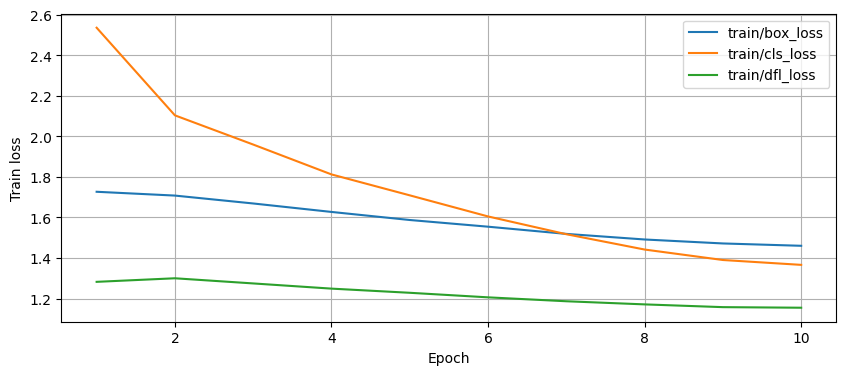

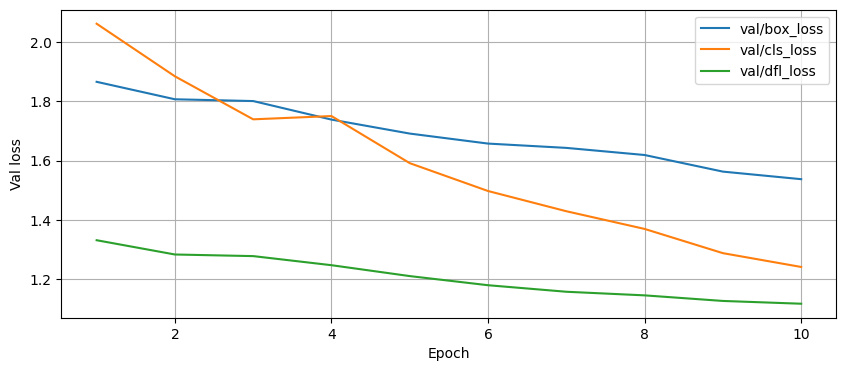

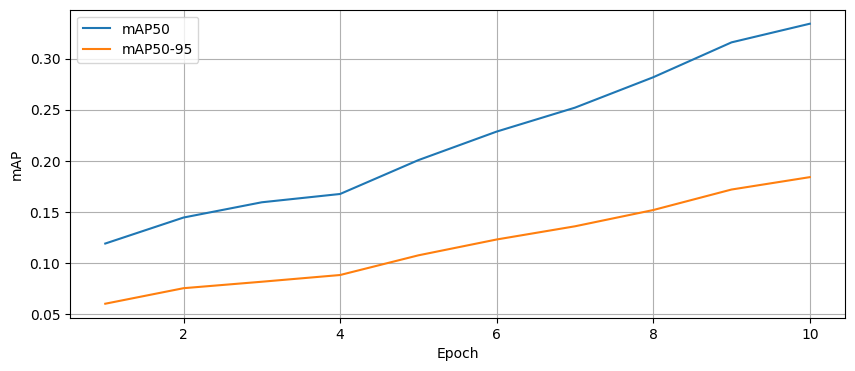

In [27]:
plt.figure(figsize=(10,4))
plt.plot(df["epoch"], df["train/box_loss"], label="train/box_loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="train/cls_loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="train/dfl_loss")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(df["epoch"], df["val/box_loss"], label="val/box_loss")
plt.plot(df["epoch"], df["val/cls_loss"], label="val/cls_loss")
plt.plot(df["epoch"], df["val/dfl_loss"], label="val/dfl_loss")
plt.xlabel("Epoch")
plt.ylabel("Val loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.legend()
plt.grid()
plt.show()


In [31]:
from ultralytics import YOLO

DATA_YAML = "/content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/data.yaml"

best_model = YOLO("/content/runs/detect/train2/weights/best.pt")
best_metrics = best_model.val(
    data=DATA_YAML,
    imgsz=640,
    batch=39,
    device=0,
)

print("BEST.PT:")
print("mAP50:     ", best_metrics.box.map50)
print("mAP50-95:  ", best_metrics.box.map)

last_model = YOLO("/content/runs/detect/train2/weights/last.pt")
last_metrics = last_model.val(
    data=DATA_YAML,
    imgsz=640,
    batch=39,
    device=0,
)

print("\nLAST.PT:")
print("mAP50:     ", last_metrics.box.map50)
print("mAP50-95:  ", last_metrics.box.map)


Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.0 ms, read: 98.3±35.6 MB/s, size: 301.6 KB)
val: Scanning /content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/val.cache... 1453 images, 99 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1453/1453 1.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 1.0it/s 37.5s
                   all       1453      35585      0.436      0.358      0.334      0.184
            pedestrian        985       7450      0.477      0.524      0.504      0.241
                person        895       6395      0.592      0.305      0.366      0.136
               bicycle        413        730      0.355      0.127      0.135     0.0667
                   car       1040      10419      0.696      0.707      0.729      0.474
                 

In [32]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train2/weights/last.pt")

results = model.train(
    data=str(DATA_YAML),
    epochs=10,
    imgsz=640,
    batch=39,
    device=0,
    amp=True,
    rect=True,
    patience=5,
    cos_lr=True,
    optimizer="AdamW",
    lr0=5e-4,
    weight_decay=0.01,
    warmup_epochs=2,
    warmup_momentum=0.8,
    warmup_bias_lr=0.05,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=0.8,
    close_mosaic=3,
    workers=8,
    name="train23",
    resume=False,
)


Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=39, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=3, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/train2/weights/last.pt, momentum=0.937, mosaic=0.8, multi_scale=False, name=train232, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam

In [34]:

DATASETS_DIR   = Path("/content/drive/MyDrive/datasets")
VISDRONE_ROOT  = DATASETS_DIR / "VisDrone"

TEST_IMG_DIR   = VISDRONE_ROOT / "images" / "test"
TEST_LBL_DIR   = VISDRONE_ROOT / "labels" / "test"
TEST_COCO_JSON = VISDRONE_ROOT / "annotations" / "visdrone_test_coco.json"

print("Test images dir:", TEST_IMG_DIR)
print("Test labels dir:", TEST_LBL_DIR)
print("Test COCO json:", TEST_COCO_JSON)


Test images dir: /content/drive/MyDrive/datasets/VisDrone/images/test
Test labels dir: /content/drive/MyDrive/datasets/VisDrone/labels/test
Test COCO json: /content/drive/MyDrive/datasets/VisDrone/annotations/visdrone_test_coco.json


In [37]:
if not TEST_COCO_JSON.exists():
    print("Test COCO JSON not found, building from YOLO labels...")
    build_coco_from_yolo(TEST_IMG_DIR, TEST_LBL_DIR, TEST_COCO_JSON)
else:
    print("Test COCO JSON already exists.")


Test COCO JSON not found, building from YOLO labels...
Processing image 50/1610: 0000074_03738_d_0000007.jpg
Processing image 100/1610: 0000118_02632_d_0000077.jpg
Processing image 150/1610: 0000265_01500_d_0000004.jpg
Processing image 200/1610: 0000320_00750_d_0000007.jpg
Processing image 250/1610: 0000370_00000_d_0000250.jpg
Processing image 300/1610: 9999938_00000_d_0000048.jpg
Processing image 350/1610: 9999938_00000_d_0000098.jpg
Processing image 400/1610: 9999938_00000_d_0000148.jpg
Processing image 450/1610: 9999938_00000_d_0000198.jpg
Processing image 500/1610: 9999938_00000_d_0000248.jpg
Processing image 550/1610: 9999938_00000_d_0000298.jpg
Processing image 600/1610: 9999938_00000_d_0000348.jpg
Processing image 650/1610: 9999938_00000_d_0000398.jpg
Processing image 700/1610: 9999938_00000_d_0000448.jpg
Processing image 750/1610: 9999938_00000_d_0000498.jpg
Processing image 800/1610: 9999941_00000_d_0000032.jpg
Processing image 850/1610: 9999952_00000_d_0000016.jpg
Processing 

In [45]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
from pathlib import Path
from tqdm import tqdm

VISDRONE_ROOT = Path("/content/drive/MyDrive/datasets/VisDrone")

TEST_IMG_DIR = VISDRONE_ROOT / "images/test"
TEST_ANN_PATH = VISDRONE_ROOT / "annotations/visdrone_test_coco.json"

MODEL_PATH = "/content/runs/detect/train232/weights/best.pt"

print("Test images:", TEST_IMG_DIR)
print("Test annotation file:", TEST_ANN_PATH)

coco_gt = COCO(str(TEST_ANN_PATH))
if "info" not in coco_gt.dataset:
    coco_gt.dataset["info"] = {
        "description": "VisDrone test annotations",
        "version": "1.0",
    }

img_id_by_name = {
    img_dict["file_name"]: img_dict["id"]
    for img_dict in coco_gt.dataset["images"]
}
print("Num GT images in annotation:", len(img_id_by_name))

detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=MODEL_PATH,
    confidence_threshold=0.25,
    device="cuda:0",
)

predictions = []
image_files = sorted(
    [p for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() in [".jpg", ".png", ".jpeg"]]
)
print(f"Running SAHI on {len(image_files)} images...")

missing_in_gt = 0

for img_path in tqdm(image_files, desc="Running SAHI inference (full)"):
    result = get_sliced_prediction(
        str(img_path),
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
    )

    img_filename = img_path.name
    img_id = img_id_by_name.get(img_filename, None)

    if img_id is None:
        stem = img_path.stem
        for k, v in coco_gt.imgs.items():
            if v["file_name"].startswith(stem):
                img_id = k
                break

    if img_id is None:
        missing_in_gt += 1
        print("WARNING: image not in annotation file:", img_filename)
        continue

    for obj in result.object_prediction_list:
        x, y, w, h = obj.bbox.to_xywh()
        predictions.append(
            {
                "image_id": img_id,
                "category_id": obj.category.id,
                "bbox": [x, y, w, h],
                "score": float(obj.score.value),
            }
        )

print(f"Images skipped (not in GT): {missing_in_gt}")

pred_json_path = "/content/visdrone_test_sahi_detections_FULL.json"
with open(pred_json_path, "w") as f:
    json.dump(predictions, f)
print("Saved FULL detections to:", pred_json_path)

coco_dt = coco_gt.loadRes(pred_json_path)
coco_eval = COCOeval(coco_gt, coco_dt, "bbox")

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()


Test images: /content/drive/MyDrive/datasets/VisDrone/images/test
Test annotation file: /content/drive/MyDrive/datasets/VisDrone/annotations/visdrone_test_coco.json
loading annotations into memory...
Done (t=0.26s)
creating index...
index created!
Num GT images in annotation: 1610
Running SAHI on 1610 images...


Running SAHI inference (full):   0%|          | 0/1610 [00:00<?, ?it/s]

Performing prediction on 8 slices.


Running SAHI inference (full):   0%|          | 1/1610 [00:00<14:58,  1.79it/s]

Performing prediction on 8 slices.


...

Performing prediction on 12 slices.


Running SAHI inference (full): 100%|█████████▉| 1609/1610 [10:07<00:00,  1.42it/s]

Performing prediction on 12 slices.


Running SAHI inference (full): 100%|██████████| 1610/1610 [10:08<00:00,  2.65it/s]


Images skipped (not in GT): 0
Saved FULL detections to: /content/visdrone_test_sahi_detections_FULL.json
Loading and preparing results...
DONE (t=0.55s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=25.07s).
Accumulating evaluation results...
DONE (t=1.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.111
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.190
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.114
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.056
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.184
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.264
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.060
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.147
 Average Recall     (AR) @[ IoU=0.50:0.95 

In [51]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(DATA_YAML),
    epochs=20,
    imgsz=640,
    batch=39,
    device=0,
    amp=True,
    rect=True,
    patience=5,
    cos_lr=True,
    optimizer="AdamW",
    lr0=5e-4,
    weight_decay=0.01,
    warmup_epochs=2,
    warmup_momentum=0.8,
    warmup_bias_lr=0.05,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=0.8,
    close_mosaic=3,
    workers=8,
    name="train_head_only",
    resume=False,
    freeze=18,
)


Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=39, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=3, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/datasets/VisDrone_sliced640_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=18, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.8, multi_scale=False, name=train_head_only5, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patie

In [52]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
from pathlib import Path
from tqdm import tqdm

VISDRONE_ROOT = Path("/content/drive/MyDrive/datasets/VisDrone")

TEST_IMG_DIR = VISDRONE_ROOT / "images/test"
TEST_ANN_PATH = VISDRONE_ROOT / "annotations/visdrone_test_coco.json"

MODEL_PATH = " /content/runs/detect/train_head_only5/weights/best.pt"

print("Test images:", TEST_IMG_DIR)
print("Test annotation file:", TEST_ANN_PATH)

coco_gt = COCO(str(TEST_ANN_PATH))
if "info" not in coco_gt.dataset:
    coco_gt.dataset["info"] = {
        "description": "VisDrone test annotations",
        "version": "1.0",
    }

img_id_by_name = {
    img_dict["file_name"]: img_dict["id"]
    for img_dict in coco_gt.dataset["images"]
}
print("Num GT images in annotation:", len(img_id_by_name))

detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=MODEL_PATH,
    confidence_threshold=0.25,
    device="cuda:0",
)

predictions = []
image_files = sorted(
    [p for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() in [".jpg", ".png", ".jpeg"]]
)
print(f"Running SAHI on {len(image_files)} images...")

missing_in_gt = 0

for img_path in tqdm(image_files, desc="Running SAHI inference (full)"):
    result = get_sliced_prediction(
        str(img_path),
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
    )

    img_filename = img_path.name
    img_id = img_id_by_name.get(img_filename, None)

    if img_id is None:
        stem = img_path.stem
        for k, v in coco_gt.imgs.items():
            if v["file_name"].startswith(stem):
                img_id = k
                break

    if img_id is None:
        missing_in_gt += 1
        print("image not in annotation file:", img_filename)
        continue

    for obj in result.object_prediction_list:
        x, y, w, h = obj.bbox.to_xywh()
        predictions.append(
            {
                "image_id": img_id,
                "category_id": obj.category.id,
                "bbox": [x, y, w, h],
                "score": float(obj.score.value),
            }
        )

print(f"Images skipped (not in GT): {missing_in_gt}")

pred_json_path = "/content/visdrone_test_sahi_detections_HEAD.json"
with open(pred_json_path, "w") as f:
    json.dump(predictions, f)
print("Saved FULL detections to:", pred_json_path)

coco_dt = coco_gt.loadRes(pred_json_path)
coco_eval = COCOeval(coco_gt, coco_dt, "bbox")

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()


Test images: /content/drive/MyDrive/datasets/VisDrone/images/test
Test annotation file: /content/drive/MyDrive/datasets/VisDrone/annotations/visdrone_test_coco.json
loading annotations into memory...
Done (t=0.37s)
creating index...
index created!
Num GT images in annotation: 1610
Running SAHI on 1610 images...


Running SAHI inference (full):   0%|          | 0/1610 [00:00<?, ?it/s]

Performing prediction on 8 slices.


Running SAHI inference (full):   0%|          | 1/1610 [00:00<13:39,  1.96it/s]

Performing prediction on 8 slices.


...

Performing prediction on 12 slices.


Running SAHI inference (full): 100%|█████████▉| 1609/1610 [08:27<00:00,  2.85it/s]

Performing prediction on 12 slices.


Running SAHI inference (full): 100%|██████████| 1610/1610 [08:27<00:00,  3.17it/s]


Images skipped (not in GT): 0
Saved FULL detections to: /content/visdrone_test_sahi_detections_HEAD.json
Loading and preparing results...
DONE (t=0.20s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=18.46s).
Accumulating evaluation results...
DONE (t=0.87s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.065
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.114
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.066
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.027
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.125
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.238
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.039
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.092
 Average Recall     (AR) @[ IoU=0.50:0.95 

In [7]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
from pathlib import Path
from tqdm import tqdm

VISDRONE_ROOT = Path("/content/drive/MyDrive/datasets/VisDrone")

TEST_IMG_DIR = VISDRONE_ROOT / "images/test"
TEST_ANN_PATH = VISDRONE_ROOT / "annotations/visdrone_test_coco.json"

MODEL_PATH = " yolov8n.pt"

print("Test images:", TEST_IMG_DIR)
print("Test annotation file:", TEST_ANN_PATH)

coco_gt = COCO(str(TEST_ANN_PATH))
if "info" not in coco_gt.dataset:
    coco_gt.dataset["info"] = {
        "description": "VisDrone test annotations",
        "version": "1.0",
    }

img_id_by_name = {
    img_dict["file_name"]: img_dict["id"]
    for img_dict in coco_gt.dataset["images"]
}
print("Num GT images in annotation:", len(img_id_by_name))

detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=MODEL_PATH,
    confidence_threshold=0.25,
    device="cuda:0",
)

predictions = []
image_files = sorted(
    [p for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() in [".jpg", ".png", ".jpeg"]]
)
print(f"Running SAHI on {len(image_files)} images...")

missing_in_gt = 0

for img_path in tqdm(image_files, desc="Running SAHI inference (full)"):
    result = get_sliced_prediction(
        str(img_path),
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
    )

    img_filename = img_path.name
    img_id = img_id_by_name.get(img_filename, None)

    if img_id is None:
        stem = img_path.stem
        for k, v in coco_gt.imgs.items():
            if v["file_name"].startswith(stem):
                img_id = k
                break

    if img_id is None:
        missing_in_gt += 1
        print("WARNING: image not in annotation file:", img_filename)
        continue

    for obj in result.object_prediction_list:
        x, y, w, h = obj.bbox.to_xywh()
        predictions.append(
            {
                "image_id": img_id,
                "category_id": obj.category.id,
                "bbox": [x, y, w, h],
                "score": float(obj.score.value),
            }
        )

print(f"Images skipped (not in GT): {missing_in_gt}")

pred_json_path = "/content/visdrone_test_sahi_detections_BASE.json"
with open(pred_json_path, "w") as f:
    json.dump(predictions, f)
print("Saved FULL detections to:", pred_json_path)

coco_dt = coco_gt.loadRes(pred_json_path)
coco_eval = COCOeval(coco_gt, coco_dt, "bbox")

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()


Test images: /content/drive/MyDrive/datasets/VisDrone/images/test
Test annotation file: /content/drive/MyDrive/datasets/VisDrone/annotations/visdrone_test_coco.json
loading annotations into memory...
Done (t=0.24s)
creating index...
index created!
Num GT images in annotation: 1610
Running SAHI on 1610 images...


Running SAHI inference (full):   0%|          | 0/1610 [00:00<?, ?it/s]

Performing prediction on 8 slices.


Running SAHI inference (full):   0%|          | 1/1610 [00:00<09:54,  2.70it/s]

Performing prediction on 8 slices.


...

Performing prediction on 12 slices.


Running SAHI inference (full): 100%|█████████▉| 1609/1610 [09:07<00:00,  2.83it/s]

Performing prediction on 12 slices.


Running SAHI inference (full): 100%|██████████| 1610/1610 [09:07<00:00,  2.94it/s]


Images skipped (not in GT): 0
Saved FULL detections to: /content/visdrone_test_sahi_detections_BASE.json
Loading and preparing results...
DONE (t=0.33s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=8.05s).
Accumulating evaluation results...
DONE (t=0.74s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.008
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.015
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.007
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.005
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.032
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.057
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.006
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.015
 Average Recall     (AR) @[ IoU=0.50:0.95 |

In [8]:
from ultralytics import YOLO
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
from pathlib import Path
from tqdm import tqdm

VISDRONE_ROOT = Path("/content/drive/MyDrive/datasets/VisDrone")

TEST_IMG_DIR  = VISDRONE_ROOT / "images/test"
TEST_ANN_PATH = VISDRONE_ROOT / "annotations/visdrone_test_coco.json"

MODEL_PATH = "yolov8n.pt"

print("Test images:", TEST_IMG_DIR)
print("Test annotation file:", TEST_ANN_PATH)

coco_gt = COCO(str(TEST_ANN_PATH))
if "info" not in coco_gt.dataset:
    coco_gt.dataset["info"] = {
        "description": "VisDrone test annotations",
        "version": "1.0",
    }

img_id_by_name = {
    img_dict["file_name"]: img_dict["id"]
    for img_dict in coco_gt.dataset["images"]
}
print("Num GT images in annotation:", len(img_id_by_name))

model = YOLO(MODEL_PATH)

predictions = []
image_files = sorted(
    [p for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() in [".jpg", ".png", ".jpeg"]]
)
print(f"Running YOLO on {len(image_files)} images...")

missing_in_gt = 0

for img_path in tqdm(image_files, desc="Running YOLO inference (base)"):
    results = model(
        source=str(img_path),
        conf=0.25,
        verbose=False
    )[0]

    img_filename = img_path.name
    img_id = img_id_by_name.get(img_filename, None)

    if img_id is None:
        stem = img_path.stem
        for k, v in coco_gt.imgs.items():
            if v["file_name"].startswith(stem):
                img_id = k
                break

    if img_id is None:
        missing_in_gt += 1
        print("WARNING: image not in annotation file:", img_filename)
        continue

    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        w = x2 - x1
        h = y2 - y1


        category_id = int(box.cls[0].item())
        score = float(box.conf[0].item())

        predictions.append(
            {
                "image_id": img_id,
                "category_id": category_id,
                "bbox": [x1, y1, w, h],
                "score": score,
            }
        )

print(f"Images skipped (not in GT): {missing_in_gt}")

pred_json_path = "/content/visdrone_test_yolo_base_detections.json"
with open(pred_json_path, "w") as f:
    json.dump(predictions, f)
print("Saved BASE YOLO detections to:", pred_json_path)

coco_dt = coco_gt.loadRes(pred_json_path)
coco_eval = COCOeval(coco_gt, coco_dt, "bbox")

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()


Test images: /content/drive/MyDrive/datasets/VisDrone/images/test
Test annotation file: /content/drive/MyDrive/datasets/VisDrone/annotations/visdrone_test_coco.json
loading annotations into memory...
Done (t=0.24s)
creating index...
index created!
Num GT images in annotation: 1610
Running YOLO on 1610 images...


Running YOLO inference (base): 100%|██████████| 1610/1610 [00:46<00:00, 34.81it/s]


Images skipped (not in GT): 0
Saved BASE YOLO detections to: /content/visdrone_test_yolo_base_detections.json
Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.62s).
Accumulating evaluation results...
DONE (t=0.45s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.005
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.014
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.059
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.004
 Average Recall     (AR) @[ IoU=0.50:0

In [ ]:
detections = []

img_files = sorted([
    p for p in TEST_IMG_DIR.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
])

for img_path in tqdm(img_files, desc="SAHI sliced inference on test"):
    file_name = img_path.name
    if file_name not in imgid_by_filename:

        continue
    image_id = imgid_by_filename[file_name]

    result = get_sliced_prediction(
        str(img_path),
        detection_model,
        slice_height=SLICE_H,
        slice_width=SLICE_W,
        overlap_height_ratio=OVERLAP_H,
        overlap_width_ratio=OVERLAP_W,
        perform_standard_pred=False,
        verbose=0,
    )

    for obj in result.object_prediction_list:
        bbox = obj.bbox
        cat_name = obj.category.name
        score = float(obj.score.value)

        if cat_name not in catid_by_name:
            continue
        cat_id = catid_by_name[cat_name]

        detections.append({
            "image_id": image_id,
            "category_id": cat_id,
            "bbox": [
                float(bbox.minx),
                float(bbox.miny),
                float(bbox.width),
                float(bbox.height),
            ],
            "score": score,
        })

print("Total detections:", len(detections))

with open(DET_JSON, "w") as f:
    json.dump(detections, f)

print("Saved detections to:", DET_JSON)
